In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from pathlib import Path

In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT/ "datasets"
COLLEGEBOARD_DIR = DATA_DIR / "collegeboard"

FRED_PATH = DATA_DIR / "fred"

PREDICTION_DIR = DATA_DIR / "predictions"

In [4]:
df_first = pd.read_excel(COLLEGEBOARD_DIR / "College Board finances 2007-2025.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jake/UC-Application-Cost-Analysis/datasets/collegeboard/College Board finances 2007-2025.xlsx'

In [121]:
df_first.columns = df_first.columns.str.replace("\n", "")
df_first = df_first.loc[:, ["TaxYear", "# of APExams","AP ExamFee"]]
df_first = df_first.astype("Int64")

In [122]:
df = df_first.copy()

df.columns = ["year", "num_exams", "exam_fee"]

df = df.sort_values("year")
df = df[df["exam_fee"].notna()]
df


,year,num_exams,exam_fee
18,2007,2533431,83
17,2008,2736445,83
16,2009,2929929,86
15,2010,3213225,86
14,2011,3456020,87
13,2012,3698407,87
12,2013,3938100,89
11,2014,4176200,89
10,2015,4478936,91
9,2016,4704980,92


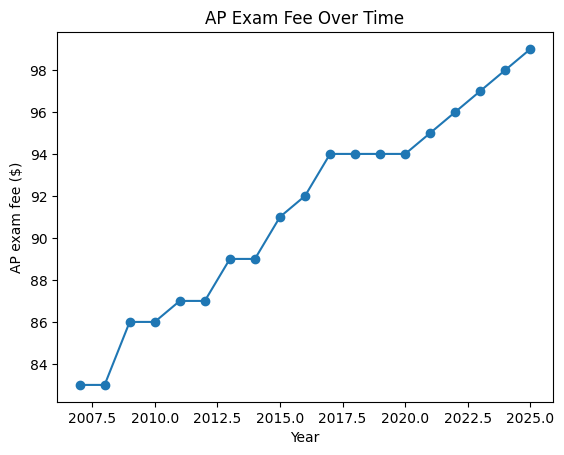

In [123]:
import matplotlib.pyplot as plt

plt.plot(df["year"], df["exam_fee"], marker="o")
plt.xlabel("Year")
plt.ylabel("AP exam fee ($)")
plt.title("AP Exam Fee Over Time")
plt.show()


In [124]:
# inflation data
cpi_historical = pd.read_csv(FRED_PATH / "CPIAUCSL.csv")

# getting most recent year of application fee data; inflation data should never bottleneck
cpi_historical.iloc[:, 0] = cpi_historical.iloc[:,0].map(lambda date : re.search(r"\d{4}", date).group())
cpi_historical = cpi_historical.astype(float)
cpi_historical = cpi_historical.rename(columns={"observation_date" : "year"})

# 2024 dollars baseline
base_year = 2024
baseyear_cpi = cpi_historical[cpi_historical["year"] == base_year]["CPIAUCSL"].values
print(baseyear_cpi)

# Create a new DataFrame to hold the inflation-adjusted exam fees
inflation_adjusted = pd.merge(df, cpi_historical, on="year", how="inner")
inflation_adjusted["exam_fee"] = inflation_adjusted["exam_fee"].mul(baseyear_cpi / inflation_adjusted.iloc[: , -1], axis = 0)
inflation_adjusted = inflation_adjusted.iloc[:, 0:-1]
inflation_adjusted = inflation_adjusted.rename(columns={"exam_fee" : "exam_fee_real"})
inflation_adjusted

[313.698]


,year,num_exams,exam_fee_real
0,2007,2533431,125.573607
1,2008,2736445,120.959118
2,2009,2929929,125.733591
3,2010,3213225,123.709294
4,2011,3456020,121.338085
5,2012,3698407,118.873651
6,2013,3938100,119.849248
7,2014,4176200,117.944034
8,2015,4478936,120.448427
9,2016,4704980,120.248395


In [125]:
# Train linear regression model to find the average increase in real exam fee per year
from sklearn.linear_model import LinearRegression

X = inflation_adjusted["year"].values.reshape(-1, 1)
y = inflation_adjusted["exam_fee_real"].values

model = LinearRegression()
model.fit(X, y)

print("slope (real $ per year):", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))


slope (real $ per year): -1.4787642727331247
intercept: 3096.393040782827
R^2: 0.803818528858637


In [126]:
# Predict future exam fees in real 2024 dollars for the next 5 years
last_year = inflation_adjusted["year"].max()  # should be 2025
future_years = np.arange(last_year + 1, last_year + 6)  # 2026-2030
future_X = future_years.reshape(-1, 1)

future_fees_real_2024 = model.predict(future_X)

future_df = pd.DataFrame({
    "year": future_years,
    "predicted_exam_fee_real_2024": future_fees_real_2024
})
future_df

,year,predicted_exam_fee_real_2024
0,2026,100.416624
1,2027,98.937860
2,2028,97.459096
3,2029,95.980331
4,2030,94.501567


In [127]:
# Save the linear regression and inflation_adjusted data into a csv

first_year = inflation_adjusted["year"].min()
all_years = [year for year in range(first_year, last_year + 6)]
lin_reg_values = model.predict(pd.DataFrame(all_years))
lin_reg_csv = pd.DataFrame({"YEAR": all_years, 
                            "predicted_exam_fee_2024base" : lin_reg_values})
lin_reg_csv.to_csv(PREDICTION_DIR / "ap_exam_fee_predictions_inflation.csv", index = False)
inflation_adjusted.to_csv(PREDICTION_DIR / "ap_exam_fee_historicals_inflation_2024base.csv", index = False)
lin_reg_csv

,YEAR,predicted_exam_fee_2024base
0,2007,128.513145
1,2008,127.034381
2,2009,125.555617
3,2010,124.076853
4,2011,122.598088
5,2012,121.119324
6,2013,119.640560
7,2014,118.161795
8,2015,116.683031
9,2016,115.204267


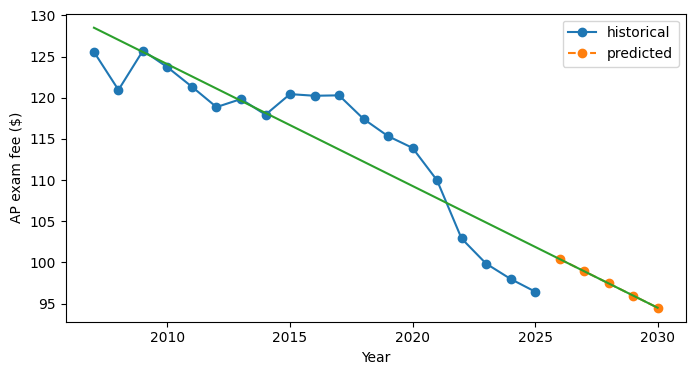

In [128]:
# Combine historical and predicted inlfation adjusted data for plotting
all_inflation = pd.concat([
    inflation_adjusted[["year", "exam_fee_real"]].rename(columns={"exam_fee": "fee"}),
    future_df.rename(columns={"predicted_exam_fee": "fee"})
], ignore_index=True)

plt.figure(figsize=(8,4))
plt.plot(inflation_adjusted["year"], inflation_adjusted["exam_fee_real"], "o-", label="historical")
plt.plot(future_years, future_fees_real_2024, "o--", label="predicted")

plt.plot(lin_reg_csv.set_index("YEAR"))

plt.xlabel("Year")
plt.ylabel("AP exam fee ($)")
plt.legend()
plt.show()
